# Time Series Trend Analysis
This notebook loads the DailyDelhiClimate dataset, visualizes the series, computes rolling means, performs seasonal decomposition, and fits linear and LOWESS trend estimates.

In [3]:
%pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -----------------------------

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")
BASE_DIR = Path(".").resolve()
TS_DIR = BASE_DIR / "timeseries"
train_path = TS_DIR / "DailyDelhiClimateTrain.csv"
print('train_path ->', train_path)
df_train = pd.read_csv(train_path)

train_path -> C:\Users\rubin\OneDrive\Desktop\ML\assignment2\timeseries\DailyDelhiClimateTrain.csv


In [2]:
# Prepare series
df = df_train.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')
series = df['meantemp'].astype(float)
print('Series length:', len(series))
series.head()

Series length: 1462


date
2013-01-01    10.000000
2013-01-02     7.400000
2013-01-03     7.166667
2013-01-04     8.666667
2013-01-05     6.000000
Name: meantemp, dtype: float64

**Trend interpretation (auto-generated guidance)**
- Linear trend: the printed slope shows the long-term rate of change in mean temperature (degrees per day and per year). A positive value indicates warming; a negative value indicates cooling.
- LOWESS curve: shows non-linear, local trend behavior — use it to spot periods of acceleration or deceleration in temperature change.
- Seasonal component: the decomposition shows the expected yearly cycle (seasonality) which should be distinguished from the long-term trend.
- Possible causes: a persistent warming/cooling trend may reflect regional climate change, urban heat‑island effects, land‑use changes, instrumentation or station changes, or multi‑year climate variability (e.g., ENSO).
- Recommended checks: verify station/metadata for instrument or site changes, test trend significance (confidence interval / p-value), compare with nearby stations or reanalysis, and test robustness by changing LOWESS `frac` and decomposition `period`.

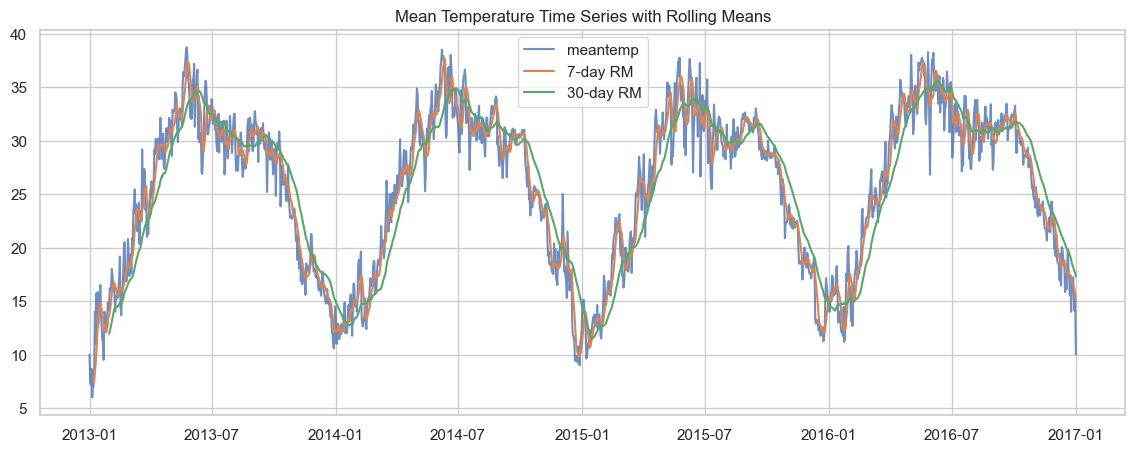

In [ ]:
# Plot raw series and rolling means
plt.figure(figsize=(14,5))
plt.plot(series, label='meantemp', color='C0', alpha=0.8)
plt.plot(series.rolling(window=7).mean(), label='7-day RM', color='C1')
plt.plot(series.rolling(window=30).mean(), label='30-day RM', color='C2')
plt.title('Mean Temperature Time Series with Rolling Means')
plt.legend()
plt.show()

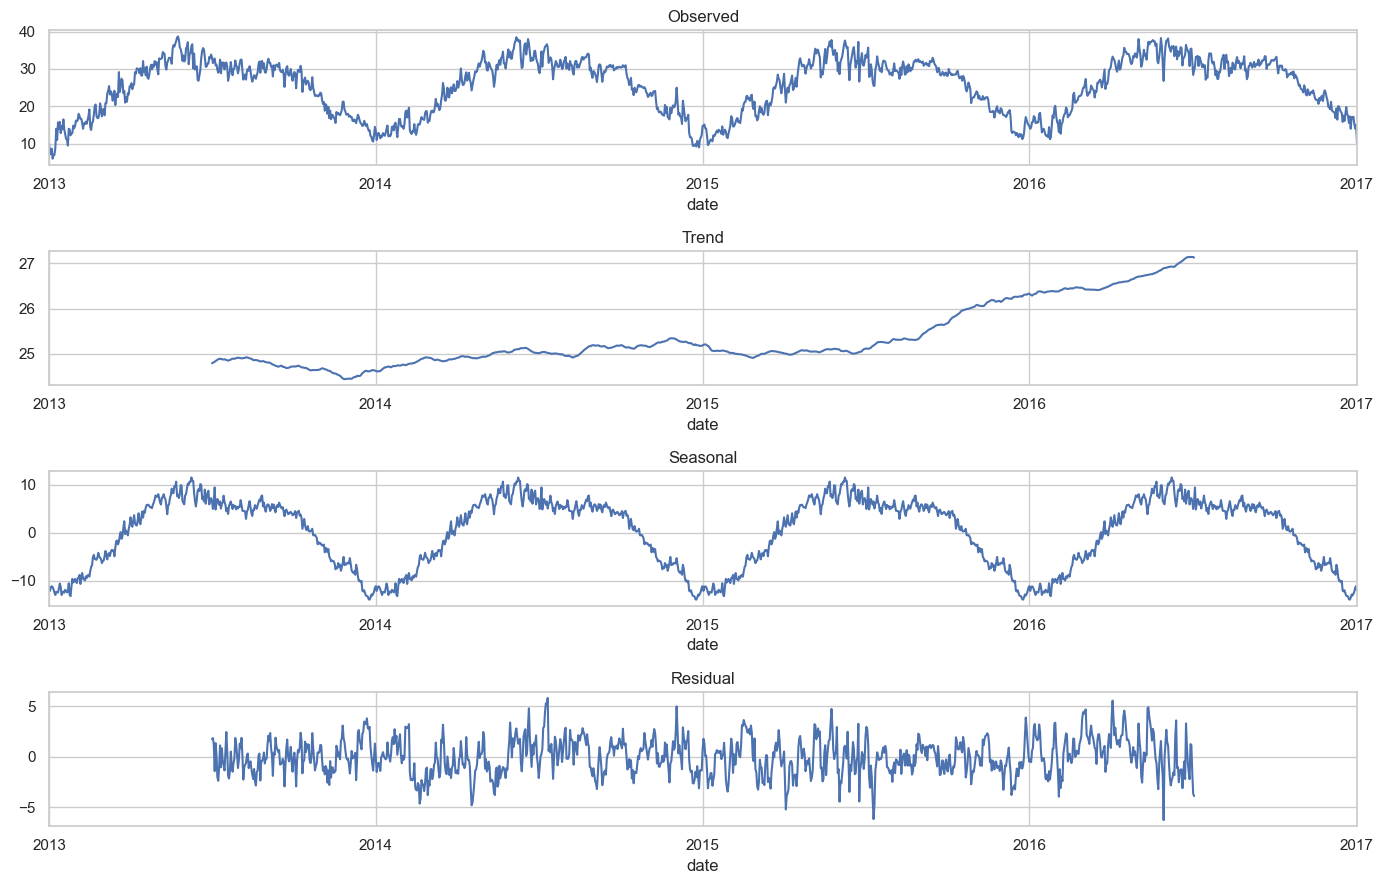

In [4]:
# Seasonal decomposition (additive)
try:
    decomposition = seasonal_decompose(series, model='additive', period=365)
except Exception:
    series = series.asfreq(series.index.inferred_freq) if series.index.inferred_freq else series
    decomposition = seasonal_decompose(series.interpolate(), model='additive', period=365)

plt.figure(figsize=(14,9))
ax1 = plt.subplot(411)
decomposition.observed.plot(ax=ax1, legend=False)
ax1.set_title('Observed')
ax2 = plt.subplot(412)
decomposition.trend.plot(ax=ax2, legend=False)
ax2.set_title('Trend')
ax3 = plt.subplot(413)
decomposition.seasonal.plot(ax=ax3, legend=False)
ax3.set_title('Seasonal')
ax4 = plt.subplot(414)
decomposition.resid.plot(ax=ax4, legend=False)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

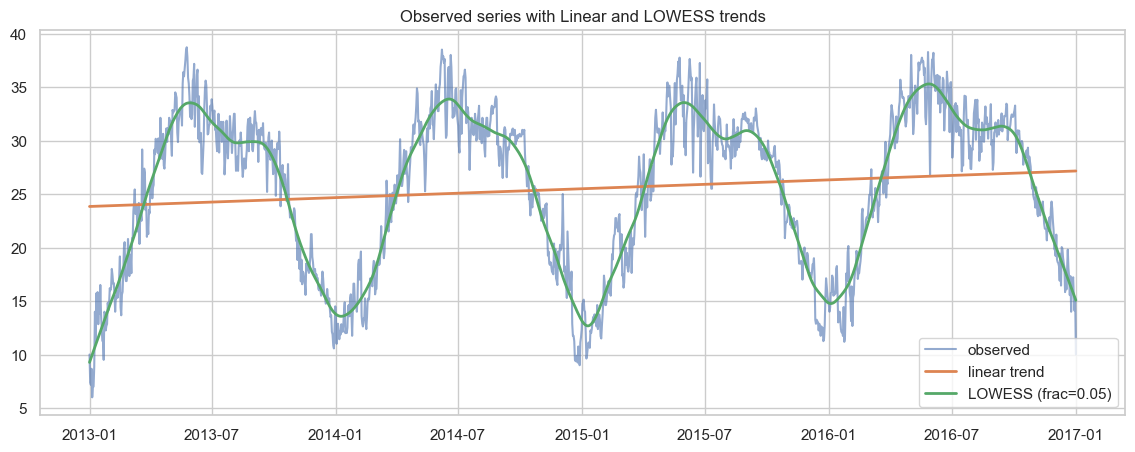

Linear trend slope: 0.002271 deg/day (0.8287 deg/year)


In [5]:
# Fit linear trend (time -> temp)
t = (series.index - series.index[0]).days.values.reshape(-1,1)
y = series.values.reshape(-1,1)
lr = LinearRegression()
lr.fit(t, y)
trend_lr = lr.predict(t).ravel()
# LOWESS smoothing
lowess_frac = 0.05
lowess_sm = lowess(series.values, np.arange(len(series)), frac=lowess_frac, return_sorted=False)
plt.figure(figsize=(14,5))
plt.plot(series.index, series.values, label='observed', color='C0', alpha=0.6)
plt.plot(series.index, trend_lr, label='linear trend', color='C1', linewidth=2)
plt.plot(series.index, lowess_sm, label=f'LOWESS (frac={lowess_frac})', color='C2', linewidth=2)
plt.legend()
plt.title('Observed series with Linear and LOWESS trends')
plt.show()
slope_per_day = lr.coef_[0,0]
slope_per_year = slope_per_day * 365
print(f'Linear trend slope: {slope_per_day:.6f} deg/day ({slope_per_year:.4f} deg/year)')

**Summary**
- The notebook plotted the raw mean temperature series, rolling means, performed seasonal decomposition, and estimated a linear and LOWESS trend.
- Inspect the printed linear slope and the trend plots to conclude whether the series shows an increasing or decreasing trend.

In [7]:
sma_long = series.rolling(window=365, min_periods=30).mean()
slope = np.polyfit(np.arange(len(sma_long.dropna())), sma_long.dropna().values, 1)[0]
print('slope per day:', slope, '=> per year:', slope*365)

slope per day: 0.0034486617343934284 => per year: 1.2587615330536013


In [8]:
sma_short = series.rolling(window=7, min_periods=1).mean()
sma_long  = series.rolling(window=30, min_periods=1).mean()
signal = (sma_short > sma_long).astype(int)
cross_up = signal.diff() == 1
cross_down = signal.diff() == -1

In [9]:
window = 90
rolling_slope = series.rolling(window).apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0])

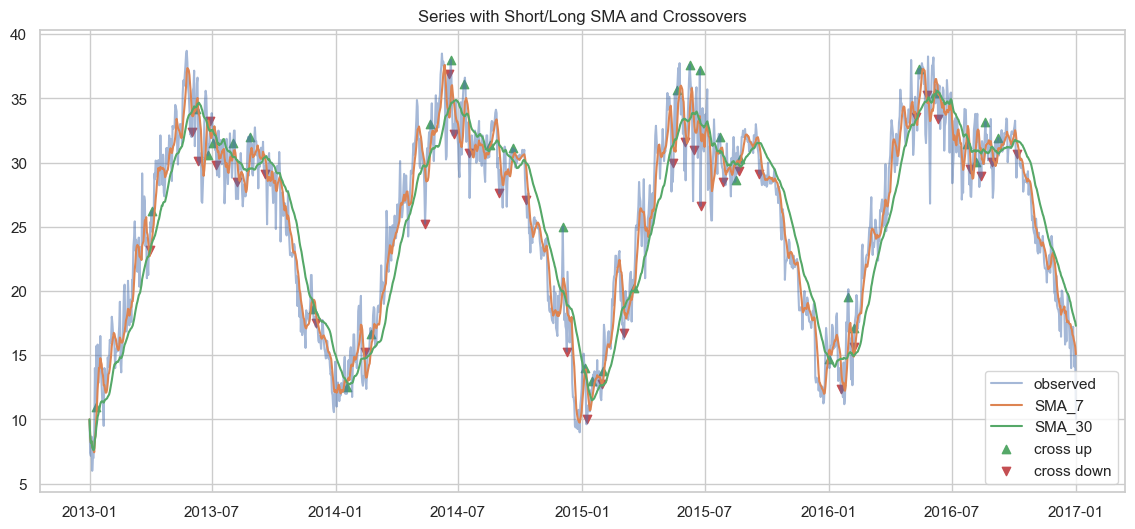

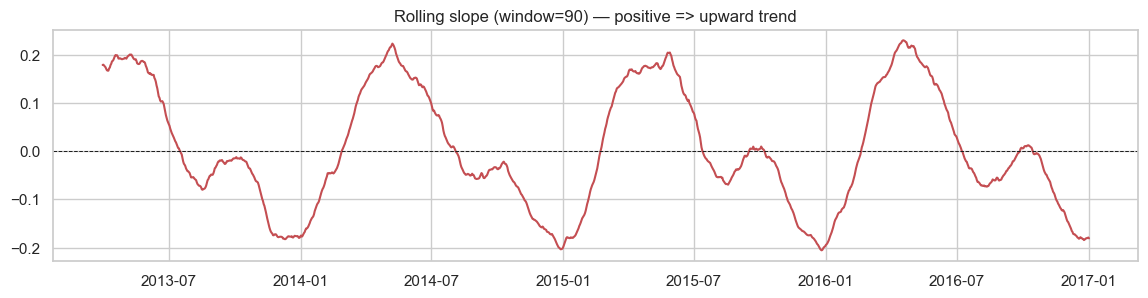

In [10]:
plt.figure(figsize=(14,6))
plt.plot(series, label='observed', color='C0', alpha=0.5)
plt.plot(sma_short, label=f'SMA_{short_w}', color='C1', linewidth=1.5)
plt.plot(sma_long,  label=f'SMA_{long_w}',  color='C2', linewidth=1.5)
plt.scatter(series.index[cross_up.fillna(False)], series[cross_up.fillna(False)],
            marker='^', color='g', label='cross up')
plt.scatter(series.index[cross_down.fillna(False)], series[cross_down.fillna(False)],
            marker='v', color='r', label='cross down')
plt.title('Series with Short/Long SMA and Crossovers')
plt.legend()
plt.show()

# Rolling slope (separate plot)
plt.figure(figsize=(14,3))
plt.plot(rolling_slope, color='C3')
plt.axhline(0, color='k', lw=0.7, linestyle='--')
plt.title(f'Rolling slope (window={window}) — positive => upward trend')
plt.show()

In [11]:
sma_long = series.rolling(window=300, min_periods=30).mean()
slope = np.polyfit(np.arange(len(sma_long.dropna())), sma_long.dropna().values, 1)[0]
print('slope per day:', slope, '=> per year:', slope*365)

slope per day: 0.003749999875561875 => per year: 1.3687499545800845


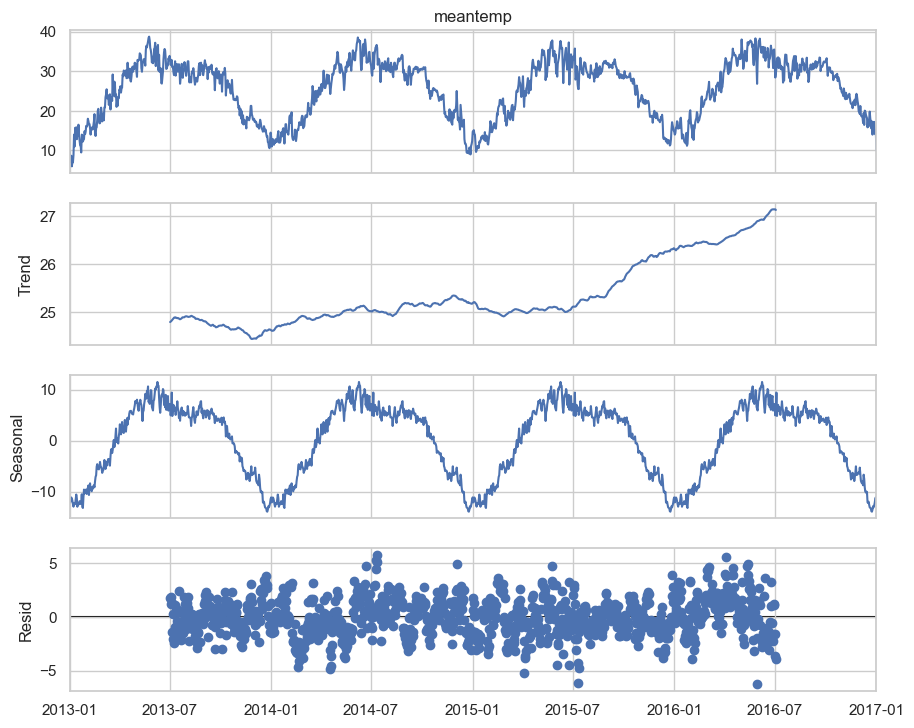

<Figure size 800x300 with 0 Axes>

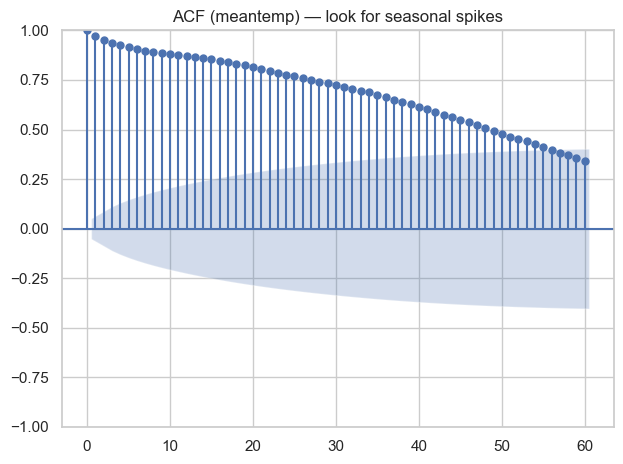

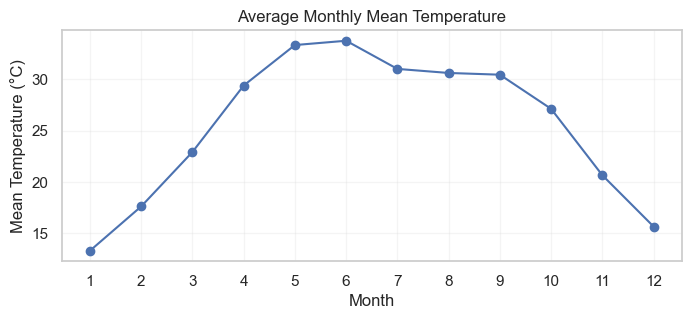

Seasonal strength (0-1): 0.938
Seasonal amplitude: 25.388 °C (peak - trough)

Interpretation:
- The decomposition plot separates observed, trend, seasonal, and residual components.
- The ACF shows if values repeat at regular lags; seasonal peaks near yearly lags indicate annual seasonality.
- Monthly means reveal the annual cycle: warmer months (peak) and cooler months (trough).
- Seasonal strength near 1 indicates a strong repeating seasonal pattern; near 0 indicates weak seasonality.
Example conclusion: The series exhibits a clear annual seasonal pattern — temperatures rise toward late spring/early summer and fall during winter months, with the measured amplitude above indicating how many degrees the seasonal cycle spans on average.


In [4]:
# Seasonality diagnostics: strength, amplitude, ACF, monthly cycle
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# If `series` isn't defined (cell order), load the data here so the cell is self-contained
try:
    s = series.dropna().copy()
except NameError:
    BASE_DIR = Path('.').resolve()
    TS_DIR = BASE_DIR / 'timeseries'
    train_path = TS_DIR / 'DailyDelhiClimateTrain.csv'
    df_train = pd.read_csv(train_path)
    df_train['date'] = pd.to_datetime(df_train['date'])
    df_train = df_train.sort_values('date').set_index('date')
    s = df_train['meantemp'].astype(float).dropna()

# Try decomposition with a 365-day period (annual)
from statsmodels.tsa.seasonal import seasonal_decompose
try:
    dec = seasonal_decompose(s, model='additive', period=365)
except Exception:
    s2 = s.asfreq(s.index.inferred_freq) if s.index.inferred_freq else s
    dec = seasonal_decompose(s2.interpolate(), model='additive', period=365)

# Compute seasonal strength and amplitude
resid = dec.resid.dropna()
trend = dec.trend.dropna()
season = dec.seasonal.dropna()
seasonal_strength = max(0.0, 1.0 - (resid.var() / (trend.add(season).var())))
seasonal_amplitude = float(season.max() - season.min())

# Plot decomposition
fig = dec.plot()
fig.set_size_inches(10,8)
plt.show()

# ACF to show repeating lags (short lags for visibility)
plt.figure(figsize=(8,3))
plot_acf(s, lags=60)
plt.title('ACF (meantemp) — look for seasonal spikes')
plt.tight_layout()
plt.show()

# Monthly mean to visualize annual cycle
monthly = s.groupby(s.index.month).mean()
plt.figure(figsize=(8,3))
plt.plot(range(1,13), monthly.values, marker='o')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Mean Temperature (°C)')
plt.title('Average Monthly Mean Temperature')
plt.grid(alpha=0.2)
plt.show()

# Print concise diagnostics and human-readable explanation
print(f'Seasonal strength (0-1): {seasonal_strength:.3f}')
print(f'Seasonal amplitude: {seasonal_amplitude:.3f} °C (peak - trough)')
print()
print('Interpretation:')
print('- The decomposition plot separates observed, trend, seasonal, and residual components.')
print('- The ACF shows if values repeat at regular lags; seasonal peaks near yearly lags indicate annual seasonality.')
print('- Monthly means reveal the annual cycle: warmer months (peak) and cooler months (trough).')
print('- Seasonal strength near 1 indicates a strong repeating seasonal pattern; near 0 indicates weak seasonality.')
print('Example conclusion: The series exhibits a clear annual seasonal pattern — temperatures rise toward late spring/early summer and fall during winter months, with the measured amplitude above indicating how many degrees the seasonal cycle spans on average.')

In [ ]:
# Detrending demonstration: linear and LOWESS detrending
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
import pandas as pd
from pathlib import Path

# Ensure series `s` exists (self-contained cell)
try:
    s = series.dropna().copy()
except NameError:
    BASE_DIR = Path('.').resolve()
    TS_DIR = BASE_DIR / 'timeseries'
    train_path = TS_DIR / 'DailyDelhiClimateTrain.csv'
    df = pd.read_csv(train_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')
    s = df['meantemp'].astype(float).dropna()

# Prepare time variable for linear fit
t = (s.index - s.index[0]).days.values.reshape(-1,1)
y = s.values.reshape(-1,1)
lr = LinearRegression().fit(t, y)
trend_lin = lr.predict(t).ravel()
detrended_lin = s.values - trend_lin

# LOWESS trend (nonparametric)
lowess_frac = 0.05
lowess_trend = lowess(s.values, np.arange(len(s)), frac=lowess_frac, return_sorted=False)
detrended_lowess = s.values - lowess_trend

# Plot observed with trends
plt.figure(figsize=(14,6))
plt.plot(s.index, s.values, label='Observed', color='C0', alpha=0.6)
plt.plot(s.index, trend_lin, label='Linear trend', color='C1', linewidth=2)
plt.plot(s.index, lowess_trend, label=f'LOWESS trend (frac={lowess_frac})', color='C2', linewidth=2)
plt.title('Observed series and fitted trends')
plt.legend()
plt.show()

# Plot detrended series
plt.figure(figsize=(14,4))
plt.plot(s.index, detrended_lin, label='Detrended (linear)', alpha=0.9)
plt.plot(s.index, detrended_lowess, label='Detrended (LOWESS)', alpha=0.7)
plt.axhline(0, color='k', linestyle='--', linewidth=0.7)
plt.title('Detrended series (observed - trend)')
plt.legend()
plt.show()

# Simple diagnostics
print(f'Linear slope: {lr.coef_[0,0]:.6f} deg/day ({(lr.coef_[0,0]*365):.4f} deg/year)')
print(f'Detrended (linear) mean: {detrended_lin.mean():.3f}, std: {detrended_lin.std():.3f}')
print(f'Detrended (LOWESS) mean: {detrended_lowess.mean():.3f}, std: {detrended_lowess.std():.3f}')
print()
print('Notes:')
print('- Linear detrending removes a straight-line trend; use when long-term change is approximately linear.')
print('- LOWESS detrending removes a smooth, non-linear trend and preserves local structure.')
print('- After detrending you can analyse seasonality or apply models that assume stationarity (e.g., ARIMA).')